In [121]:
# Установка необходимых версий для верного воспроизведения
# При работе в Colab возможно понадобится перезапуск среды, при повторной инсталляции numpy
# При работе в Colab обязательно выберите: Среда выполнения -> GPU -> Версия 2026.04
!pip uninstall gym-super-mario-bros nes-py -y
!pip install -q gym-super-mario-bros==7.3.0 nes-py==8.2.1
!pip install 'numpy<2.0.0'
!pip install -q stable-baselines3
!pip install 'shimmy>=2.0'

Found existing installation: gym-super-mario-bros 7.3.0
Uninstalling gym-super-mario-bros-7.3.0:
  Successfully uninstalled gym-super-mario-bros-7.3.0
Found existing installation: nes_py 8.2.1
Uninstalling nes_py-8.2.1:
  Successfully uninstalled nes_py-8.2.1


# Семинар 13. Обучение с подкреплением (`RL`)

# 1. Курс молодого бойца

Перед началом работы, давайте вспомним основные определения, которые у нас были на лекции:

1. **Среда (Environment)** Мир, с которым агент взаимодействует и на котором учится.

2. **Действие (Action)** $a \in \mathcal{A}$: То, как агент отвечает на действия среды. Множество всех возможных действий $\mathcal{A}$ называется *пространством действий (`action-space`)*.

3. **Состояние (State)** $s \in \mathcal{S}$: Текущая характеристика среды. Множество всех возможных состояний $\mathcal{S}$, в которых может находиться среда, называется *пространством состояний (`state-space`)*.

4. **Награда (Reward)** $r: \mathcal{S} \times \mathcal{A} \to \mathbb{R}$: Награда — это ключевая обратная связь от среды к агенту. Именно она побуждает агента учиться и изменять свои будущие действия. Агрегация $R$ наград за несколько временных шагов (при горизонте $h$) называется **Возвратом** (`Return`).

$$R = \mathbb{E}[r_0 + \gamma r_1 + \gamma^2 r_2 + ... + \gamma^k r_k + ...] = \mathbb{E}[{\sum_{t=0}^{\infty} \gamma^t r_t}]$$

5. **Политика** - это некоторое вероятностное распределение $\pi(a|s)$, которое зачастую порождается алгоритмами обучения с учителем `SL`.


Сегодня мы посмотрим как можно обучить агента взаимодействовать со средой на примере игры Mario SuperBros

![alt](https://raw.githubusercontent.com/AlexanderZiyatdinov/ML-UrFU/main/13-RL/data/mario.gif)

In [122]:
# Импортируем игру
import gym_super_mario_bros
# Импортируем Joypad пространство (пространство с уменьшенным кол-вом состояний)
from nes_py.wrappers import JoypadSpace
# Действия и управляющие элементы
from gym_super_mario_bros.actions import SIMPLE_MOVEMENT
import gym

# Для нормально рендеринга в Colab
from gym.wrappers import RecordVideo
from IPython.display import Video
import shutil
import glob
import time

## 2. Начинаем работать со средой

Давайте для начала посмотрим на наши базовые действия, т. е. на $\mathcal{A}$.

Стоит сразу отметить, что пространство действий может быть задано по-разному. Это может быть игроко-подобное поведение из 7 различных действий, а может быть и больше, например 256 действий (технически возможное управление всеми битами состояния контроллера)

In [123]:
SIMPLE_MOVEMENT  # Базовые "человеческие" действия

[['NOOP'],
 ['right'],
 ['right', 'A'],
 ['right', 'B'],
 ['right', 'A', 'B'],
 ['A'],
 ['left']]

Давайте создадим окружение. При создании мы можем указать конкретный дискретный элемент окружения. Наше окружение (игру) можно представить в виде дискретного множества континуальных пространств состояний. Или более простыми словами: уровней у нас **конечное число**, а вот состояний на уровне бесконечно (с т. з. инженерии, математически, конечно, тоже дискретно).

![alt](https://raw.githubusercontent.com/AlexanderZiyatdinov/ML-UrFU/main/13-RL/data/levels.png)

In [124]:
# Создадим окружение
env = gym_super_mario_bros.make('SuperMarioBros-v0')

/usr/local/lib/python3.12/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment SuperMarioBros-v0 is out of date. You should consider upgrading to version `v3`.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [125]:
# Можем посмотреть на изначальное состояние действий:
# Их как раз 256, как и говорилось ранее
env.action_space

Discrete(256)

Конечно, 256 различных действий - это лишь технически возможные состояния. Однако стоит признать, что большинство из них излишние, давайте перейдем в более человечное пространство, к более человечному поведению

In [126]:
# Создаём JoypadSpace с базовыми действиями (actions)
env = JoypadSpace(env, SIMPLE_MOVEMENT)

In [127]:
# Пространство действий
env.action_space

Discrete(7)

На лекции мы уже обсуждали, что делать в случае континуального $\mathcal{S}$ и дискретного $\mathcal{A}$:

Давайте вспомним, а что вообще делает политика $\pi(a|s)$? Она задаёт вероятностное распределение действий, при условии состояния. А что может задавать распределение дискретной конечной величины, при условии картинки? Любой классификатор, который принимает на вход картинку:

* $\pi(a|s) = f_w(a, s)$  ($f$, к примеру, может быть, `RFC` или `LR` или `NN` и т.д.)
* Сэмплируем $N$ сессий с политикой $\pi$. Выбираем $M$ элитных сессий
$$Elite = [(s_0, a_0), (s_1, a_1), ..., (s_M, a_M)]$$

* Дообучаем наш классификатор, максимизируя правдоподобие:

$$\pi_{new}(a|s) =  \arg\max_{\pi}\sum_{s_t, a_t \in Elite} log \ \pi(a_i | s_i))$$

Стоит вспомнить, что изначально у нас нет никаких элитных сессий, а $\pi(a|s)$ порождено случайным образом.

In [128]:
# Сэмплируем конкретное действие со случайной политикой
# Можно позапускать эту ячейку несколько раз
action = env.action_space.sample()
SIMPLE_MOVEMENT[action]

['right', 'A', 'B']

Само же взаимодействие со средой агента с политикой $\pi (a | s)$ моделируется так:
1. Изначально среда находится в состоянии $s_0$
2. Агент сэмплирует действие из своей политики $a_0 \sim \pi (a_0 | s_0)$
3. Среда отвечает на это:
    * сэмплирует своё следующее состояние $s_1 \sim p(s_1 | s_0, a_0)$
    * Выдаёт агенту награду в размере $r(s_0, a_0)$
4. Процесс повторяется...

In [129]:
state0 = env.reset()                # Изначальное состояние среды
action0 = env.action_space.sample() # Сэмплируем конкретное действие со случайной политикой
state1 = env.step(action0)          # Среда отвечает на это новым состоянием и выдёт reward
print(state1[0])                    # В данном случае новое состояние - это RGB картинка

[[[104 136 252]
  [104 136 252]
  [104 136 252]
  ...
  [104 136 252]
  [104 136 252]
  [104 136 252]]

 [[104 136 252]
  [104 136 252]
  [104 136 252]
  ...
  [104 136 252]
  [104 136 252]
  [104 136 252]]

 [[104 136 252]
  [104 136 252]
  [104 136 252]
  ...
  [104 136 252]
  [104 136 252]
  [104 136 252]]

 ...

 [[240 208 176]
  [228  92  16]
  [228  92  16]
  ...
  [228  92  16]
  [228  92  16]
  [  0   0   0]]

 [[240 208 176]
  [228  92  16]
  [228  92  16]
  ...
  [228  92  16]
  [  0   0   0]
  [  0   0   0]]

 [[228  92  16]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [228  92  16]]]


/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:227: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(done, (bool, np.bool8)):


In [130]:
# Давайте попробуем теперь запустить 1000 таких шагов
env = gym_super_mario_bros.make('SuperMarioBros-v0')
env = JoypadSpace(env, SIMPLE_MOVEMENT)

done = True
for _ in range(1000):
    if done:
        env.reset()
    action = env.action_space.sample()
    state, reward, done, info = env.step(action)
env.close()

/usr/local/lib/python3.12/dist-packages/gym_super_mario_bros/smb_env.py:148: RuntimeWarning: overflow encountered in scalar subtract
  return (self.ram[0x86] - self.ram[0x071c]) % 256


In [131]:
# А теперь для интереса попробуем вместе с рендерингом
# В Colab сильная беда с рендерингом видео, поэтому приходится искать обходые пути в виде загрузки видео

# Очистка от старых попыток
shutil.rmtree('./video', ignore_errors=True)

# Задаём пространство, переводим его в формат рендеринга
env = gym_super_mario_bros.make('SuperMarioBros-v0')
env = JoypadSpace(env, SIMPLE_MOVEMENT)
env = RecordVideo(env, './video', episode_trigger=lambda x: True)

# Запускаем наши действия с базовой политикой π(a|s)
done = False
steps = 0
max_steps = 500

state = env.reset()
while not done and steps < max_steps:
    action = env.action_space.sample()
    state, reward, done, info = env.step(action)
    steps += 1

# Финализируем mp4 вручную
if hasattr(env, "video_recorder"):
    recorder = env.video_recorder
    if recorder is not None:
        recorder.close()

time.sleep(2)

/usr/local/lib/python3.12/dist-packages/gym/wrappers/monitoring/video_recorder.py:67: DeprecationWarning: WARN: `env.metadata["render.modes"] is marked as deprecated and will be replaced with `env.metadata["render_modes"]` see https://github.com/openai/gym/pull/2654 for more details
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/monitoring/video_recorder.py:78: DeprecationWarning: WARN: Recording ability for environment SuperMarioBros-v0 initialized with `render_mode=None` is marked as deprecated and will be removed in the future.
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/monitoring/video_recorder.py:149: DeprecationWarning: WARN: `env.metadata["video.frames_per_second"] is marked as deprecated and will be replaced with `env.metadata["render_fps"]` see https://github.com/openai/gym/pull/2654 for more details
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mo

In [132]:
# Воспроизводим видео игры нашего агента
# Пока что агент ведёт себя почти рандомно
import glob
from IPython.display import Video, display

video_files = glob.glob('./video/*.mp4')
print(video_files)

if video_files:
    display(Video(video_files[-1], embed=True, width=640))

['./video/rl-video-episode-0.mp4']


Кстати, более подробную информацию о том, как работать с `gym-super-mario-bros` можно найти [здесь](https://pypi.org/project/gym-super-mario-bros/)

## 2. Предобработка среды

Данные окружения возвращаются агенту в `next_state`. Как вы видели выше, каждое состояние представлено массивом размером `[3, 240, 256]`. Часто это больше информации, чем нужно нашему агенту; например, действия Марио не зависят от цвета труб или неба!

для предварительной обработки данных окружения перед отправкой агенту можно использовать обёртки (`Wrappers`). Они позволяют сжать информативное представление данных.

Вот некоторые из них.

1. `GrayscaleObservation` — это распространённая обёртка, которая преобразует RGB-изображение в оттенки серого; это уменьшает размер представления состояния без потери полезной информации. Теперь размер каждого состояния: `[1, 240, 256]`.

2. `ResizeObservation` уменьшает дискретизацию каждого наблюдения до квадратного изображения. Новый размер: `[1, 84, 84]`.

3. `SkipFrame` — это пользовательская обёртка, которая наследуется от `gym.wrapper` и реализует функцию `step()`. Поскольку последовательные кадры сильно не различаются, мы можем пропустить $n$ промежуточных кадров без существенной потери информации. $n$-й кадр агрегирует награды, накопленные за каждый пропущенный кадр.

4. `FrameStack` — это обёртка, которая позволяет объединить последовательные кадры окружения в одну точку наблюдения для передачи нашей обучающей модели. Таким образом, мы можем определить, приземлялся Марио или прыгал, основываясь на направлении его движения на предыдущих нескольких кадрах.

Более подробно мы не будем погружать в каждую из них. Но если кому-то интересно, то [вот](https://gymnasium.farama.org/api/wrappers/)

In [133]:
# Импортируем Frame Stacker Wrapper и GrayScaling wrapper
from gym.wrappers import FrameStack, GrayScaleObservation


from stable_baselines3.common.vec_env import VecFrameStack, DummyVecEnv
from matplotlib import pyplot as plt

In [134]:
class SB3Compat(gym.Wrapper):
    def reset(self, **kwargs):
        kwargs.pop("seed", None)
        kwargs.pop("options", None)
        obs = self.env.reset()
        if isinstance(obs, tuple):
            obs = obs[0]
        return obs, {}

    def step(self, action):
        result = self.env.step(action)
        if len(result) == 4:
            obs, reward, done, info = result
            terminated = done
            truncated = False
            return obs, reward, terminated, truncated, info
        return result

In [135]:
envName = "SuperMarioBros-2-1-v0"
env = gym_super_mario_bros.make(envName)

env = JoypadSpace(env, SIMPLE_MOVEMENT)

env = GrayScaleObservation(env, keep_dim=True)

env = SB3Compat(env)

env = DummyVecEnv([lambda: env])

env = VecFrameStack(env, 4, channels_order="last")

/usr/local/lib/python3.12/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment SuperMarioBros-2-1-v0 is out of date. You should consider upgrading to version `v3`.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium e

После применения указанных выше обёрток к окружению финальное обёрнутое состояние состоит из $4$ последовательных кадров в оттенках серого, сложенных вместе, как показано на изображении слева. Каждый раз, когда Марио выполняет действие, окружение отвечает состоянием такой структуры. Эта структура представлена трёхмерным массивом размера `[240, 256, 4]`


![alt](https://raw.githubusercontent.com/AlexanderZiyatdinov/ML-UrFU/main/13-RL/data/mario_env.png)

Давайте посмотрим на это в нашем коде:

In [136]:
state = env.reset()

In [137]:
state[0].shape

(240, 256, 4)

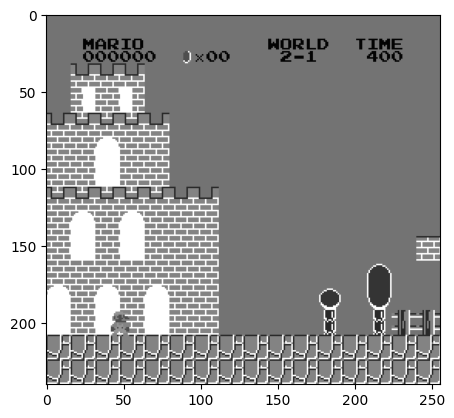

In [138]:
plt.imshow(state[0])

## 3. Работа с агентом. Обучение RL Model

Введём новое понятие

**PPO (Proximal Policy Optimization)** — это метод обучения с подкреплением, который улучшает стабильность тренировки policy, ограничивая размер обновления шага. Он относится к семейству policy gradient методов.

Вместо того чтобы просто максимизировать выгоду, PPO использует **клиппирование (clipping)**, чтобы новое policy не слишком сильно отклонялось от старого. Это предотвращает разрушительно большие обновления.


$$
r_t(\theta) = \frac{\pi_{\theta}(a_t \mid s_t)}{\pi_{\theta_{\text{old}}}(a_t \mid s_t)}
$$

При этом, целевая функция:

$$
L^{\text{CLIP}}(\theta) = \mathbb{E}_t \left[ \min \left( r_t(\theta) A_t, \ \text{clip}(r_t(\theta), 1 - \epsilon, 1 + \epsilon) A_t \right) \right]
$$

где:
- $A_t$ — **advantage** (насколько действие лучше среднего в данном состоянии),
- $\epsilon$ — гиперпараметр (обычно 0.1 или 0.2),
- $\text{clip}(x, 1 - \epsilon, 1 + \epsilon)$ — ограничивает $x$ в интервал $[1 - \epsilon, 1 + \epsilon]$.


![alt](https://raw.githubusercontent.com/AlexanderZiyatdinov/ML-UrFU/main/13-RL/data/mar.gif)

Почему это вообще работает?
- Если $A_t > 0$ (хорошее действие), $r_t(\theta)$ ограничено сверху $1 + \epsilon$ — не слишком увеличиваем вероятность.
- Если $A_t < 0$ (плохое действие), $r_t(\theta)$ ограничено снизу $1 - \epsilon$ — не слишком уменьшаем вероятность.

Если кто-то хочет изучить такой подход подробнее, то [вот](https://huggingface.co/blog/deep-rl-ppo) статья с hugginface

In [139]:
import os
# Импортируем PPO
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback

In [140]:
# Создаём директории для чекпоинтов (весов модели) и логгирования

CHECKPOINT_DIR='./train/'
LOG_DIR='./logs/'

In [141]:
# Класс для пользовательского callback

class TrainAndLoggingCallback(BaseCallback):
    def __init__(self, check_freq, save_path, verbose=1):
        super(TrainAndLoggingCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.save_path = save_path

    def _init_callback(self):
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            model_path = os.path.join(self.save_path, f'best_model_{self.n_calls}')
            print(model_path)
            self.model.save(model_path)
        return True

In [142]:
# Задаём callback на сохранение чекпоинта
callback=TrainAndLoggingCallback(check_freq=100000, save_path=CHECKPOINT_DIR)

удем обновлять нашу политику $\pi = f_w(a, s)$, в качестве $f_w(a, s)$ возьмём `CNN`. Для того, чтобы наша политика изменялась посредством обучения `CNN`, то необходимо указать параметр 'CnnPolicy'.

Внутри это чудо использует типичную архитектуру `CNN`:
* 3 `ConvLayer`
* `Flatten`
* 2 `FFCLayer`

Но бывают и другие возможности изменения политики, к примеру `MlpPolicy` или даже `CnnLstmPolicy`, но их стоит применять в других задачах и средах.

In [143]:
model = PPO(
    "CnnPolicy",
    env,
    verbose=1,
    learning_rate=1e-4,
    n_steps=512,
    batch_size=64,
)

Using cuda device
Wrapping the env in a VecTransposeImage.


In [144]:
model.learn(total_timesteps=40000)

model.save("mario_2_1_model")

----------------------------
| time/              |     |
|    fps             | 90  |
|    iterations      | 1   |
|    time_elapsed    | 5   |
|    total_timesteps | 512 |
----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 90          |
|    iterations           | 2           |
|    time_elapsed         | 11          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.010528067 |
|    clip_fraction        | 0.155       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.94       |
|    explained_variance   | -0.00468    |
|    learning_rate        | 0.0001      |
|    loss                 | 32.8        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00679    |
|    value_loss           | 132         |
-----------------------------------------


In [145]:
# Сохраним модель
model.save("mario_model_1_2")

## 4. Финальный тест на полной игре

In [146]:

# Загружаем ту модель, которую только что сохранили
model = PPO.load("mario_model_1_2")

In [147]:
# Проводим весь наш pipeline для того, чтобы верно выдавать predict
# При надобности, можно выделить функцию, реализующую такие pipelines

env = gym_super_mario_bros.make("SuperMarioBros-2-1-v0")
env = JoypadSpace(env, SIMPLE_MOVEMENT)
env = GrayScaleObservation(env, keep_dim=True)
env = SB3Compat(env)
env = DummyVecEnv([lambda: env])
env = VecFrameStack(env, 4, channels_order="last")

# Загружаем обученную модель
model = PPO.load("mario_2_1_model")

In [148]:
# Начальное состояние будет обладать значением только в финальном 4-ом столбце
# Т.к. три столбца до этого пустые (все данные склиппированы по 4 кадра)
state = env.reset()

In [149]:
state

array([[[[  0,   0,   0, 140],
         [  0,   0,   0, 140],
         [  0,   0,   0, 140],
         ...,
         [  0,   0,   0, 140],
         [  0,   0,   0, 140],
         [  0,   0,   0, 140]],

        [[  0,   0,   0, 140],
         [  0,   0,   0, 140],
         [  0,   0,   0, 140],
         ...,
         [  0,   0,   0, 140],
         [  0,   0,   0, 140],
         [  0,   0,   0, 140]],

        [[  0,   0,   0, 140],
         [  0,   0,   0, 140],
         [  0,   0,   0, 140],
         ...,
         [  0,   0,   0, 140],
         [  0,   0,   0, 140],
         [  0,   0,   0, 140]],

        ...,

        [[  0,   0,   0, 214],
         [  0,   0,   0, 124],
         [  0,   0,   0, 124],
         ...,
         [  0,   0,   0, 124],
         [  0,   0,   0, 124],
         [  0,   0,   0,   0]],

        [[  0,   0,   0, 214],
         [  0,   0,   0, 124],
         [  0,   0,   0, 124],
         ...,
         [  0,   0,   0, 124],
         [  0,   0,   0,   0],
         

In [150]:
model.predict(state)

(array([4]), None)

In [151]:
# Сброс среды в начало
state = env.reset()

# Цикл игры (5000 шагов для длинного видео)
for _ in range(5000):
    action, _ = model.predict(state)
    state, reward, done, info = env.step(action)
    if done:
        state = env.reset()

In [152]:
import shutil
import glob
from stable_baselines3 import PPO
from gym.wrappers import RecordVideo
from gym_super_mario_bros import make
from nes_py.wrappers import JoypadSpace
from gym.wrappers import GrayScaleObservation
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from gym.wrappers import FrameStack

shutil.rmtree("./final_video", ignore_errors=True)

env = make("SuperMarioBros-2-1-v0")
env = JoypadSpace(env, SIMPLE_MOVEMENT)

env = GrayScaleObservation(env, keep_dim=True)

env = RecordVideo(env, "./final_video", episode_trigger=lambda x: True)

env = DummyVecEnv([lambda: env])
env = VecFrameStack(env, 4, channels_order="last")

model = PPO.load("mario_2_1_model")

obs = env.reset()

done = False
steps = 0
max_steps = 3000

while not done and steps < max_steps:

    action, _ = model.predict(obs)

    obs, reward, done, info = env.step(action)

    steps += 1

env.close()

print("Видео записано")

TypeError: JoypadSpace.reset() got an unexpected keyword argument 'seed'

In [ ]:
video_files = glob.glob('./final_video/*.mp4')

print(video_files)

if video_files:
    display(Video(video_files[-1], embed=True, width=640))